In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('datos.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temperatura_media  200 non-null    float64
 1   gasto_consumidor   200 non-null    float64
 2   inflacion          200 non-null    float64
 3   desempleo          200 non-null    float64
 4   consumo_historico  200 non-null    float64
 5   demanda_energia    200 non-null    float64
dtypes: float64(6)
memory usage: 9.5 KB


In [4]:
df.head(10)

,temperatura_media,gasto_consumidor,inflacion,desempleo,consumo_historico,demanda_energia
0,22.483571,1571.557472,1.702786,11.513977,5750.627045,6772.955796
1,19.308678,1612.156905,2.200312,8.155669,4587.164217,6656.454041
2,23.238443,1716.610249,2.502622,11.739212,5076.896622,6152.942393
3,27.615149,1710.760410,2.523490,12.711276,4630.179769,5276.832114
4,18.829233,1224.466126,2.274967,10.826870,4652.403018,6190.866511
5,18.829315,1312.434992,2.811425,13.753592,4752.662301,6018.722038
6,27.896064,1603.007053,1.966190,8.452422,5177.707017,6070.712386
7,23.837174,1602.757190,2.428810,7.510691,4617.001103,6186.834445
8,17.652628,1603.009537,2.560148,6.442560,6004.604900,7650.371260
9,22.712800,2270.546298,2.757219,12.992089,4284.314158,6032.959879


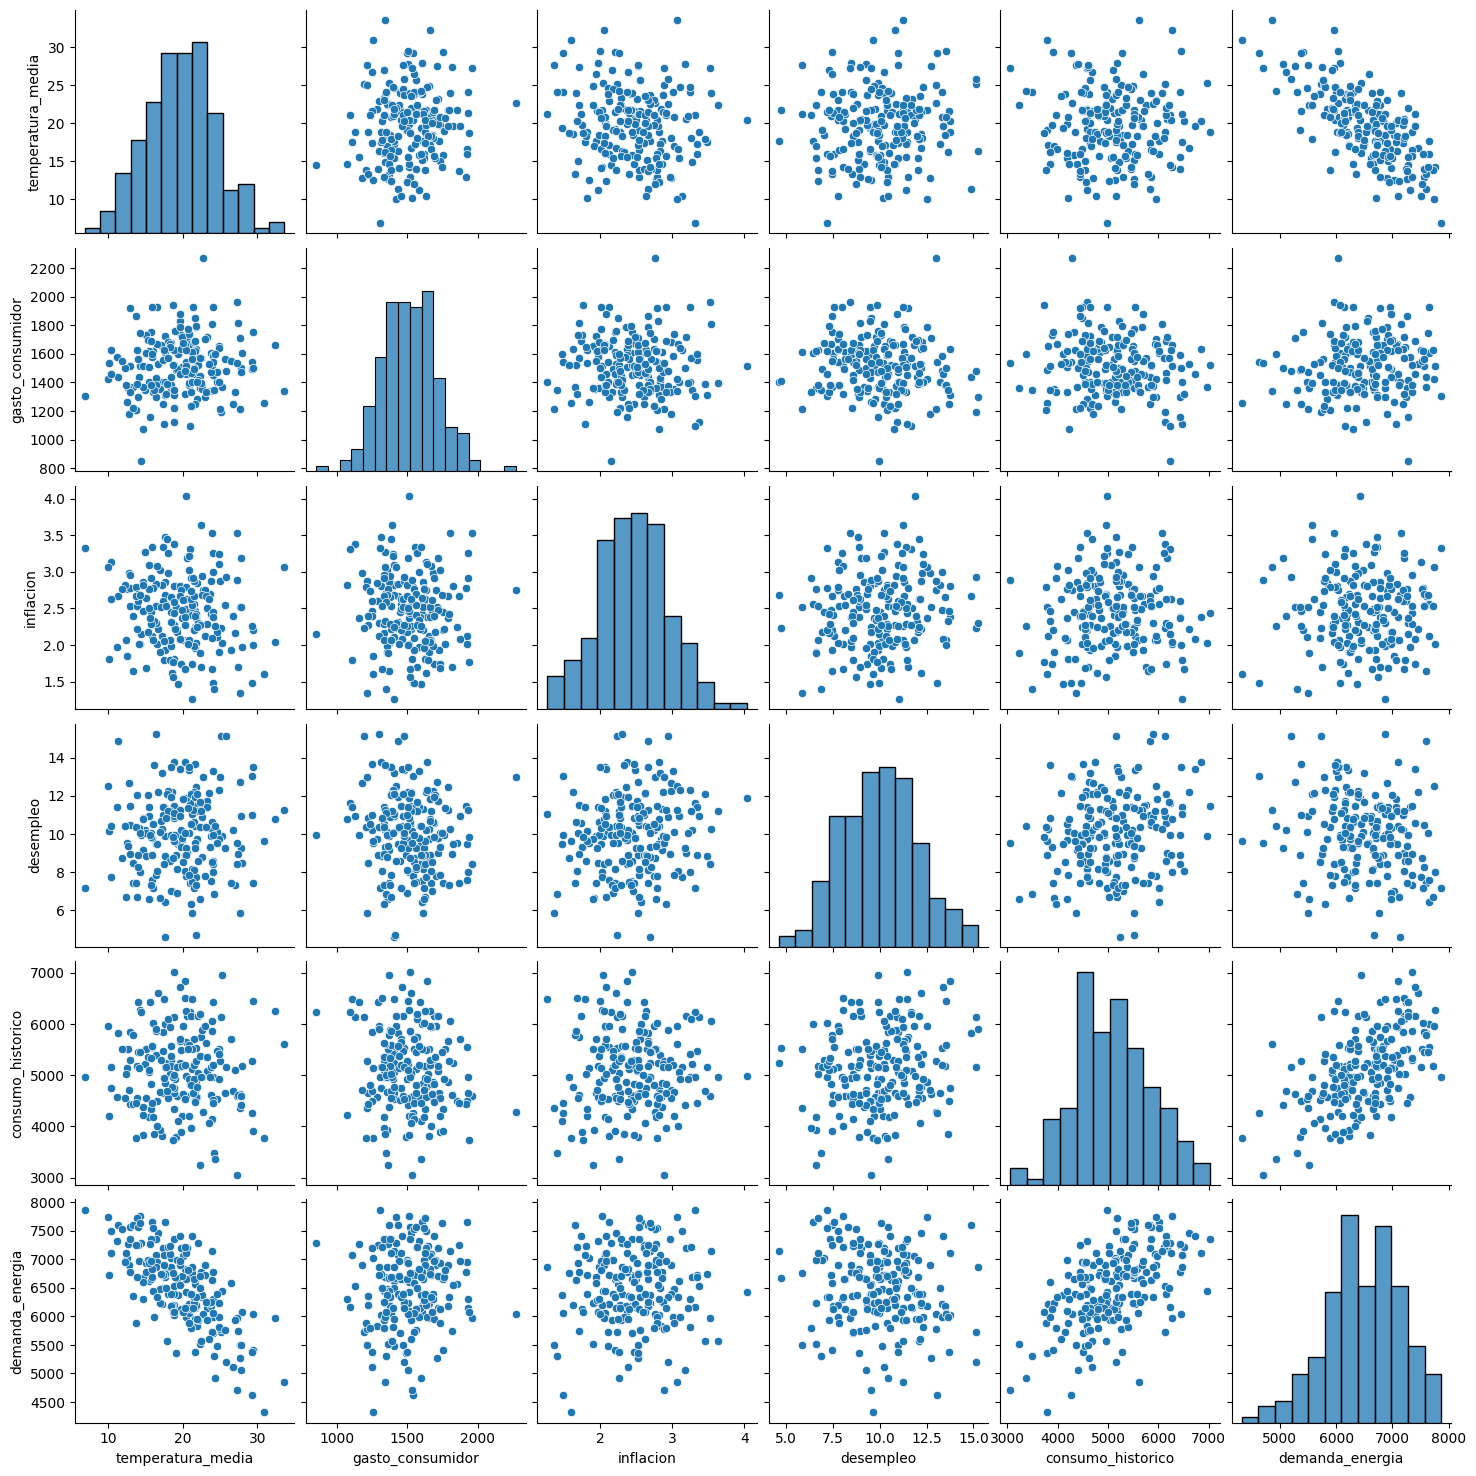

In [5]:
# Pairplot para ver posibles correlaciones entre variables
sns.pairplot(df)

<Axes: >

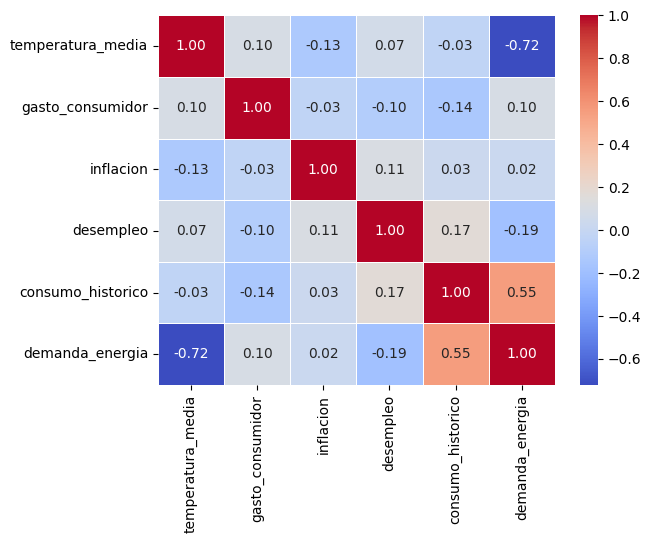

In [6]:
#calculo matriz de correlacion + mapa de calor

correlations_matrix = df.corr()

sns.heatmap(
    correlations_matrix,
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=.5,       
    cbar=True            
)


In [7]:
df.head()

,temperatura_media,gasto_consumidor,inflacion,desempleo,consumo_historico,demanda_energia
0,22.483571,1571.557472,1.702786,11.513977,5750.627045,6772.955796
1,19.308678,1612.156905,2.200312,8.155669,4587.164217,6656.454041
2,23.238443,1716.610249,2.502622,11.739212,5076.896622,6152.942393
3,27.615149,1710.760410,2.523490,12.711276,4630.179769,5276.832114
4,18.829233,1224.466126,2.274967,10.826870,4652.403018,6190.866511


<Axes: >

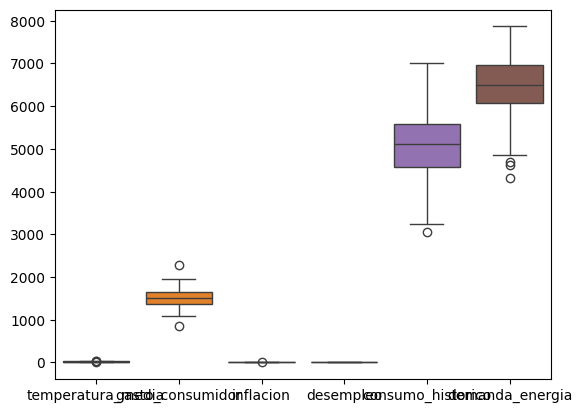

In [8]:
# Calculamos outliers de los datos. Todas las columnas parecen tener, pero no son valores atípicos, ya que cada mes puede tener
# picos de valores diferentes debido a la estación del año (verano, + aire acondicionado por ejemplo)
sns.boxplot(data=df)

In [9]:
# Escalado de valores

from sklearn.preprocessing import StandardScaler

df_features = df[['temperatura_media','gasto_consumidor','inflacion','desempleo','consumo_historico']]

scaler = StandardScaler()

# Fit-transform numeric columns
df_scaled_array = scaler.fit_transform(df_features)

df_scaled = pd.DataFrame(df_scaled_array, columns=df_features.columns)

In [10]:
df_scaled

,temperatura_media,gasto_consumidor,inflacion,desempleo,consumo_historico
0,0.578767,0.276191,-1.521625,0.735502,0.849500
1,-0.104981,0.482377,-0.518096,-0.915547,-0.675688
2,0.741336,1.012849,0.091673,0.846234,-0.033696
3,1.683908,0.983140,0.133765,1.324132,-0.619299
4,-0.208235,-1.486529,-0.367515,0.397699,-0.590167
...,...,...,...,...,...
195,0.458814,-0.563763,-0.427976,1.026709,-0.429297
196,-0.907839,-1.827265,-0.185789,-0.047710,1.750775
197,0.209434,1.287924,-0.900716,0.661278,0.537567
198,0.106582,-0.203556,-0.361693,0.019028,-0.733509


In [11]:
# Calculamos una regresión lineal para ver los coeficientes del modelo. Lo haremos sin train/test por qué ahora no nos interesa.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
X = df_scaled
y = df['demanda_energia']

In [13]:
y

0      6772.955796
1      6656.454041
2      6152.942393
3      5276.832114
4      6190.866511
          ...     
195    5948.237047
196    7270.258839
197    6810.651158
198    6151.023255
199    7632.798586
Name: demanda_energia, Length: 200, dtype: float64

In [14]:
model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
coef_df = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': model.coef_
})

print(coef_df)

            variable  coeficiente
0  temperatura_media  -483.982740
1   gasto_consumidor   153.932380
2          inflacion   -39.664755
3          desempleo  -142.893447
4  consumo_historico   403.145295


In [16]:
# parte 2 (modelos sin regularización)

In [17]:
# copiamos lo definido arriba pero ahora solo con las 3 variables que queremos trabajar

df_features = df[['temperatura_media','desempleo','consumo_historico']]

scaler = StandardScaler()

# Fit-transform numeric columns
df_scaled_array = scaler.fit_transform(df_features)

df_scaled = pd.DataFrame(df_scaled_array, columns=df_features.columns)

X = df_scaled
y = df['demanda_energia']

In [18]:
# Entrenamos el modelo de regresión lineal 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# X e y definidos arriba

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Modelo de regresión lineal simple

model_lin = LinearRegression()
model_lin.fit(X_train, y_train)

# Predicciones
y_pred = model_lin.predict(X_test)

# Métricas
print("Coeficientes:", model_lin.coef_)
print("Intercept:", model_lin.intercept_)
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Coeficientes: [-454.49085155 -163.29052349  375.90782345]
Intercept: 6486.6457062246045
R²: 0.9186782630062839
RMSE: 217.40978076108007


In [19]:
# Calculo AIC y BIC

rss = np.sum((y_test - y_pred) ** 2)

n = len(y_train)
k = X_test.shape[1] + 1   

aic = n * np.log(rss / n) + 2 * k
bic = n * np.log(rss / n) + k * np.log(n)

print("AIC:", aic)
print("BIC:", bic)

AIC: 1542.924368132026
BIC: 1555.467561880227


In [20]:
# Entrenamos el modelo polinómico de grado 2

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# X e y definidos arriba

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Grado del polinomio
degree = 2

# Pipeline polinómico
poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
    ('lin_reg', LinearRegression())
])

# Entrenamiento
poly_model.fit(X_train, y_train)

# Predicción
y_pred = poly_model.predict(X_test)

# Métricas
print(f"Modelo polinómico grado {degree}")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Modelo polinómico grado 2
R²: 0.923207968137096
RMSE: 211.2680551208012


In [21]:
poly = poly_model.named_steps['poly_features']
n_features_poly = poly.fit_transform(X_train).shape[1]

print("Número de features polinómicas:", n_features_poly)

Número de features polinómicas: 9


In [22]:
# Calculo AIC y BIC

rss = np.sum((y_test - y_pred) ** 2)

n = len(y_train)
k = n_features_poly + 1   

aic = n * np.log(rss / n) + 2 * k
bic = n * np.log(rss / n) + k * np.log(n)

print("AIC:", aic)
print("BIC:", bic)

AIC: 1545.1812489922925
BIC: 1576.5392333627951


In [23]:
# PARTE 2
# MODELOS CON REGULARIZACION (RIDGE)

In [24]:
from sklearn.linear_model import RidgeCV

# Definimos todos los modelos que se quieren comparar
models = {
    'Linear Regression': LinearRegression(),
    
    'Polynomial Regression (degree=2)': Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ]),
    
    'Ridge Regression': RidgeCV(alphas=np.logspace(-4, 4, 10), cv=5),
    
    'Polynomial Ridge (degree=2)': Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('ridge', RidgeCV(alphas=np.logspace(-4, 4, 10), cv=5))
    ])
}


In [25]:
# lista de lso resultados después de hacer cross validation
cv_results = {}

In [26]:
#entrenamos cada modelo con validacion cruzada y guardamos las metricas de evaluacion de cada modelo

from sklearn.model_selection import cross_validate

for name, model in models.items():
    cv_scores = cross_validate(
        model, 
        X_train, 
        y_train,
        cv=5,  
        scoring=['r2', 'neg_mean_squared_error'],
        return_train_score=True
    )
    
    mean_r2 = cv_scores['test_r2'].mean()
    mean_rmse = np.sqrt(-cv_scores['test_neg_mean_squared_error'].mean())
    
    cv_results[name] = {
        'mean_r2': mean_r2,
        'mean_rmse': mean_rmse,
    }
    
    print(f"\n{name}:")
    print(f"  R² = {mean_r2:.4f}")
    print(f"  RMSE = {mean_rmse:.4f}")


Linear Regression:
  R² = 0.8176
  RMSE = 271.8190

Polynomial Regression (degree=2):
  R² = 0.8083
  RMSE = 278.5296

Ridge Regression:
  R² = 0.8177
  RMSE = 271.7899

Polynomial Ridge (degree=2):
  R² = 0.8095
  RMSE = 277.7281
